<a href="https://colab.research.google.com/github/PepBiel/NLP_project/blob/main/Fornes_Reynes_JosepGabriel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Título**: Ajuste fino a T5 para Resumenes

**Alumno**: Josep Gabriel Fornes Reynes

# Introducción

Durante el desarrollo de la asignatura, hemos explorado el ajuste fino (*fine-tuning*) en distintas arquitecturas de Modelos de Lenguaje:
- **Arquitectura Encoder-only**: utilizamos el modelo **BERT** junto con el dataset *Yelp review* para tareas de **clasificación de texto** (análisis de sentimiento).
- **Arquitectura Decoder-only**: trabajamos con el modelo **Llama-2** aplicando la técnica **QLoRA** sobre el dataset *Guanaco* para la generación de texto conversacional.

Para complementar estas experiencias y cubrir el espectro completo de arquitecturas Transformer, este proyecto se centra en una arquitectura **Encoder-Decoder** (Seq2Seq). Esta arquitectura es ideal para tareas donde la entrada y la salida son secuencias de texto de longitud variable, como la traducción o el resumen.
El objetivo principal de este trabajo es realizar un resumen abstractivo de noticias. Para ello, he seleccionado el modelo **T5-small** (*Text-to-Text Transfer Transformer*) y el dataset **CNN/DailyMail**. Esta tarea presenta un desafío interesante de evaluación, ya que no se mide por exactitud (*accuracy*), sino mediante métricas de similitud de n-gramas como **ROUGE**, lo que permite analizar la capacidad del modelo para comprender y reescribir información compleja."

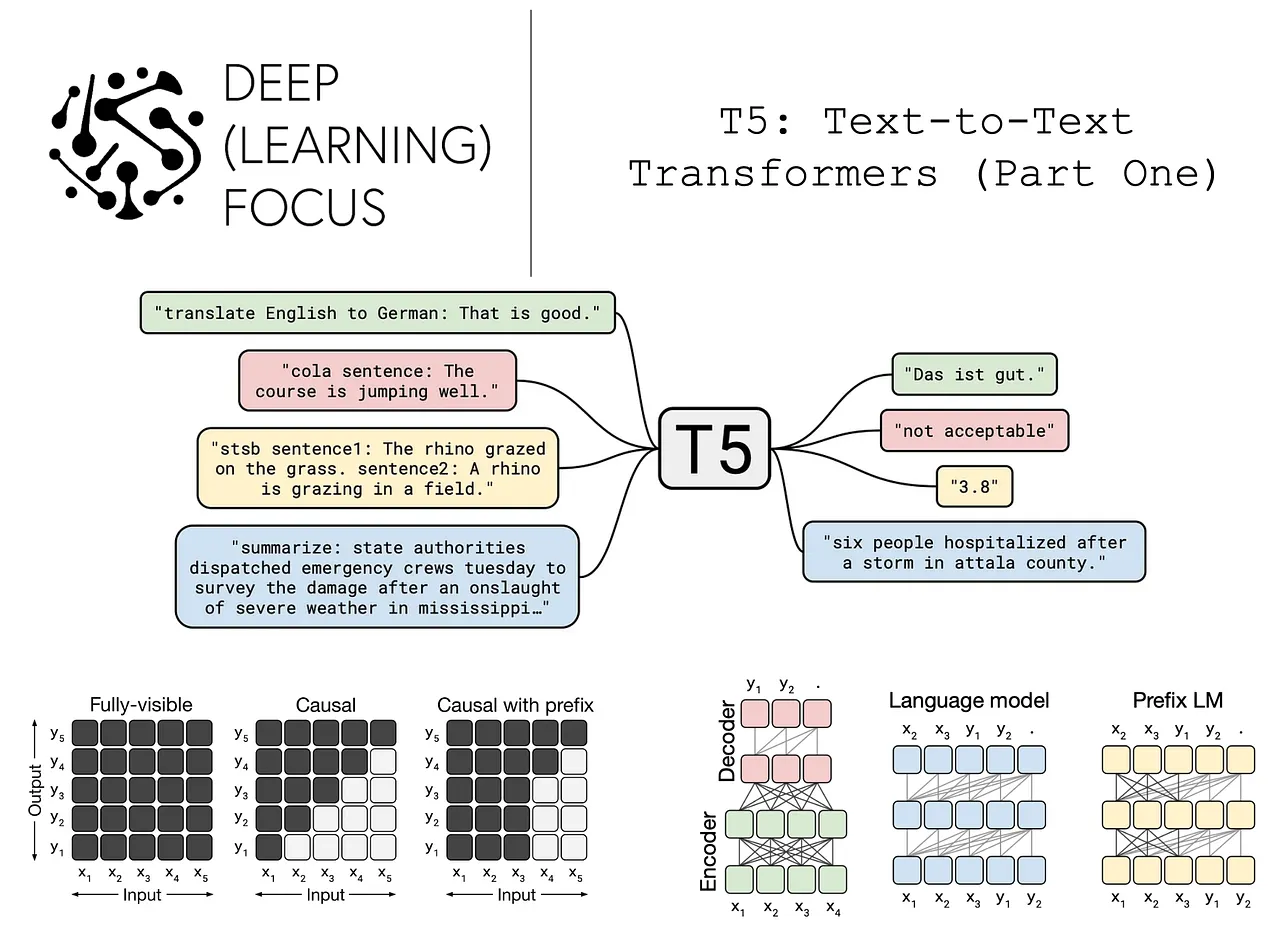

(Imágen obtenida desde [Deep (Learning) Focus](https://cameronrwolfe.substack.com/p/t5-text-to-text-transformers-part))

# Dataset

## Instalaciones necesarias

Para llevar a cabo el ajuste fino, utilizaremos el ecosistema de bibliotecas de **Hugging Face**, que se ha convertido en el estándar de la industria para NLP moderno. Las principales librerías son:
- `transformers`: El núcleo del proyecto. Nos proporciona la arquitectura del modelo T5 preentrenado y su tokenizador asociado.
- `datasets`: Fundamental para descargar y gestionar eficientemente el dataset CNN/DailyMail sin saturar la memoria RAM (gracias a su sistema de mapeo en memoria).
- `accelerate`: Optimiza el bucle de entrenamiento para que funcione de manera eficiente en la GPU T4 de Google Colab, gestionando el movimiento de tensores automáticamente.
- `evaluate`: La utilizaremos para cargar las métricas de evaluación del modelo.
- `rouge_score`: Una dependencia específica necesaria para calcular la métrica ROUGE (Recall-Oriented Understudy for Gisting Evaluation), que es el estándar académico para evaluar la calidad de los resúmenes automáticos.

In [38]:
!pip install -q transformers datasets accelerate evaluate rouge_score

In [2]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer
from datasets import load_dataset
import evaluate
import numpy as np
import torch
import matplotlib.pyplot as plt

## Selección del dataset

Para el desarrollo de este proyecto, se ha utilizado el dataset **CNN/DailyMail** (versión 3.0.0), un estándar de referencia en la comunidad de NLP para tareas de resumen abstractivo. Este conjunto de datos, consta de noticias reales en inglés emparejadas con resúmenes escritos por humanos.

In [26]:
# Cargar el dataset
dataset = load_dataset("cnn_dailymail", "3.0.0")

## Estructura de datos

Cada ejemplo del dataset contiene tres campos principales:

- `id`: Un identificador único para el artículo.

- `article`: El cuerpo del texto de la noticia (nuestra secuencia de entrada o Input).

- `highlights`: El resumen de referencia generado por humanos (nuestra secuencia objetivo).

In [23]:
# Ver la estructura de un ejemplo
print(dataset["test"][0].keys())

dict_keys(['article', 'highlights', 'id'])


## Preprocesamiento de datos

Para transformar los textos en secuencias numéricas comprensibles por el modelo, cargamos el tokenizador asociado al checkpoint `t5-small` utilizando la clase `AutoTokenizer` de la librería Transformers.

In [4]:
# Nombre del modelo
model_checkpoint = "t5-small"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

Configuramos el tokenizador para utilizar el padding a la izquierda, modificando el comportamiento por defecto del modelo para adaptarlo mejor a la generación de secuencias en lotes.

In [ ]:
tokenizer.padding_side = "left"

Definimos la función para procesar los ejemplos del dataset, la cual implementa tres pasos críticos:
1. **Prefijo de tarea**: se añade la cadena `"summarize: "` al inicio de cada artículo. Esto es fundamental para **T5**, ya que al ser un modelo entrenado en múltiples tareas (traducción, corrección, etc.), necesita este *prompt* para activar su capacidad de resumen.

2. **Gestión de longitudes**:
- **Entradas (artículos)**: Se establece una longitud máxima de 1024 tokens. Cualquier texto que exceda esta longitud se trunca, asegurando que la entrada quepa en la memoria de la GPU.

- **Salidas (resúmenes)**: Se establece una longitud máxima de 128 tokens para los resúmenes objetivo, ya que estos textos son naturalmente más breves.

In [24]:
def tokenize_function(examples):
    # Prefijo de tarea
    inputs = ["summarize: " + doc for doc in examples["article"]]

    # Gestión de longitudes
    model_inputs = tokenizer(inputs, max_length=1024, truncation=True)
    labels = tokenizer(text_target=examples["highlights"], max_length=128, truncation=True)

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

El dataset completo contiene más de 300.000 pares de noticias y resúmenes.

In [32]:
print(f"Ejemplos del dataset: {len(dataset["train"]) + len(dataset["validation"]) + len(dataset["test"])}")

Ejemplos del dataset: 311971


Dado que hay demasiados datos en este dataset, se optó por realizar un recorte estratégico de los datos.

En lugar de procesar la totalidad del dataset, se seleccionó un subconjunto aleatorio pero reproducible (utilizando una semilla `seed=42`):

- Conjunto de Entrenamiento: **1.000 ejemplos**.
- Conjunto de Validación: **200 ejemplos**.
- Conjunto de Test: **200 ejemplos**.

In [34]:
small_train_dataset = dataset["train"].shuffle(seed=42).select(range(1000))
small_eval_dataset = dataset["validation"].shuffle(seed=42).select(range(200))
small_test_dataset = dataset["test"].shuffle(seed=42).select(range(200))

print(f"Entrenamiento: {len(small_train_dataset)}, Validación: {len(small_eval_dataset)}, Prueba: {len(small_test_dataset)}")

Entrenamiento: 1000, Validación: 200, Prueba: 200


Aplicamos la función declarada anteriormente a las tres particiones del dataset.

Gracias al parámetro `batched=True`, permitimos al tokenizador procesar lotes de ejemplos simultáneamente en lugar de iterar uno por uno, reduciendo drásticamente el tiempo de preparación de los datos

In [35]:
# Aplicar la tokenización a las particiones el dataset
tokenized_train = small_train_dataset.map(tokenize_function, batched=True)
tokenized_val = small_eval_dataset.map(tokenize_function, batched=True)
tokenized_test = small_test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

dict_keys(['article', 'highlights', 'id', 'input_ids', 'attention_mask', 'labels'])


Realizamos una verificación y control de calidad:
1. **Inspección de estructura**: imprimimos las claves del primer elemento procesado para confirmar la existencia de los campos requeridos por el modelo como `input_ids` (la entrada codificada), `attention_mask` (máscara de atención) y `labels` (el objetivo codificado).

In [37]:
print(tokenized_train[0].keys())
print(tokenized_val[0].keys())
print(tokenized_test[0].keys())

dict_keys(['article', 'highlights', 'id', 'input_ids', 'attention_mask', 'labels'])
dict_keys(['article', 'highlights', 'id', 'input_ids', 'attention_mask', 'labels'])
dict_keys(['article', 'highlights', 'id', 'input_ids', 'attention_mask', 'labels'])


2. **Inspección de contenido**: Se visualizan muestras aleatorias de cada conjunto para corroborar visualmente que el texto ha sido correctamente transformado a tensores numéricos y que los prefijos de tarea se han añadido adecuadamente.

In [36]:
print(tokenized_train[0])
print(tokenized_val[1])
print(tokenized_test[2])

{'article': "By . Anthony Bond . PUBLISHED: . 07:03 EST, 2 March 2013 . | . UPDATED: . 08:07 EST, 2 March 2013 . Three members of the same family who died in a static caravan from carbon monoxide poisoning would have been unconscious 'within minutes', investigators said today. The bodies of married couple John and Audrey Cook were discovered alongside their daughter, Maureen, at the mobile home they shared on Tremarle Home Park in Camborne, west Cornwall. The inquests have now opened into the deaths last Saturday, with investigators saying the three died along with the family's pet dog, of carbon monoxide poisoning from a cooker. Tragic: The inquests have opened into the deaths of three members of the same family who were found in their static caravan last weekend. John and Audrey Cook are pictured . Awful: The family died following carbon monoxide poisoning at this caravan at the Tremarle Home Park in Camborne, Cornwall . It is also believed there was no working carbon monoxide detect

# Implementación

Tras preparar los datos, se procede al ajuste fino del modelo. Este proceso se estructura en tres etapas clave implementadas en el código:
1. Inicialización del modelo y colacionador
2. Definición de la metrica
3. Configuración del entrenamiento

## 1. Inicialización del modelo y colacionador

Se carga el modelo preentrenado `AutoModelForSeq2SeqLM` con los pesos de `T5-small`.

In [9]:
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

Para gestionar los lotes de datos durante el entrenamiento, se instancia un `DataCollatorForSeq2Seq`. Este componente es crucial en tareas de generación, ya que se encarga de aplicar *padding* dinámico tanto a las secuencias de entrada como a las etiquetas, optimizando el uso de memoria de la GPU.

In [ ]:
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

## 2. Definición de la metrica

A diferencia de la clasificación, el resumen requiere métricas de similitud de texto. Se define la función `compute_metrics`, que decodifica las predicciones generadas por el modelo y las compara con los resúmenes de referencia utilizando la métrica **ROUGE**. Esta función también gestiona el post-procesamiento necesario para ignorar los tokens de relleno (*padding tokens*, representados por -100) en el cálculo de la métrica.

In [11]:
rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # Decodificar las predicciones
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    # Reemplazar -100 en las etiquetas porque el tokenizer no puede decodificarlos
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Calcular ROUGE
    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)

    # Formatear un poco los números para que se vean bien
    prediction_lens = [np.count_nonzero(pred != tokenizer.pad_token_id) for pred in predictions]
    result["gen_len"] = np.mean(prediction_lens)

    return {k: round(v, 4) for k, v in result.items()}

## 3. Configuración del entrenamiento

Se establecen los hiperparámetros que gobernarán el proceso de aprendizaje:
- `learning_rate=2e-5`: Una tasa de aprendizaje conservadora para evitar el olvido catastrófico de los conocimientos previos del modelo.
- `per_device_train/eval_batch_size=4`: Un tamaño de lote reducido para prevenir errores de memoria.
- `weight_decay=0.01`: Se aplica una técnica de regularización (L2) para penalizar los pesos excesivamente grandes durante la optimización
- `num_train_epochs=3`: Se entrena durante 3 épocas completas para asegurar la convergencia.
- `predict_with_generate=True`: Instrucción explícita para que el modelo genere texto completo durante la evaluación, permitiendo el cálculo de ROUGE.
- `fp16=True`: Activación de precisión mixta para acelerar el entrenamiento.

In [16]:
training_args = Seq2SeqTrainingArguments(
    output_dir="modelo_resumen_t5",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=3,
    predict_with_generate=True,
    fp16=True,
    report_to="none"
)

Se instancia el `Seq2SeqTrainer` con los componentes preparados anteriormente.

In [17]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

/tmp/ipython-input-2968841388.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Ejecutamos el entrenamiento mediante el método `.train()`

In [18]:
print("--- INICIANDO ENTRENAMIENTO ---")
trainer.train()  # <--- AQUÍ OCURRE LA MAGIA (Tardará unos minutos)
print("--- ENTRENAMIENTO FINALIZADO ---")

--- INICIANDO ENTRENAMIENTO ---


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
1,No log,1.926315,0.244100,0.112200,0.201700,0.201100,19.995000
2,1.979800,1.911060,0.245800,0.110100,0.201500,0.201000,19.980000
3,1.979800,1.907193,0.245000,0.110000,0.200600,0.199900,20.000000


--- ENTRENAMIENTO FINALIZADO ---


Guardamos el modelon final por si lo necesitamos posteriormente

In [ ]:
trainer.save_model("modelo_resumen_t5_final")

# Resultados y discusión

Una vez tenemos el modelo de generación de resúmenes entrenado, tenemos que realizar la evaluación de este modelo. Para realizar esta evaluación, vamos a extrae el historial de entrenamiento (`log_history`) para generar una gráfica dual.

Esta visualización permite monitorear simultáneamente la función de pérdida (Loss, eje derecho) y la calidad del resumen (ROUGE-1, eje izquierdo) a lo largo de las épocas, proporcionando evidencia empírica del aprendizaje.

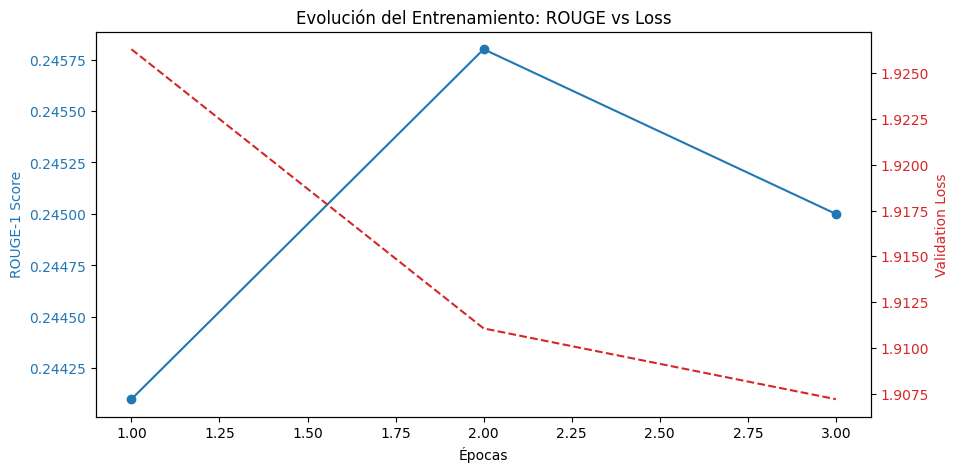

In [19]:
# Extraer el historial de entrenamiento
history = trainer.state.log_history

# Filtrar las métricas de evaluación (las que tienen ROUGE)
eval_logs = [x for x in history if 'eval_rouge1' in x]

# Si has entrenado al menos una época completa, podrás graficar
if len(eval_logs) > 0:
    epochs = [x['epoch'] for x in eval_logs]
    rouge1 = [x['eval_rouge1'] for x in eval_logs]
    loss = [x['eval_loss'] for x in eval_logs]

    # Crear gráfica
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Eje izquierdo: ROUGE (Queremos que suba)
    color = 'tab:blue'
    ax1.set_xlabel('Épocas')
    ax1.set_ylabel('ROUGE-1 Score', color=color)
    ax1.plot(epochs, rouge1, color=color, marker='o', label='Calidad Resumen (ROUGE)')
    ax1.tick_params(axis='y', labelcolor=color)

    # Eje derecho: LOSS (Queremos que baje)
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Validation Loss', color=color)
    ax2.plot(epochs, loss, color=color, linestyle='--', label='Error (Loss)')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Evolución del Entrenamiento: ROUGE vs Loss')
    plt.show()
else:
    print("No hay suficientes datos de evaluación para graficar (¿quizás solo entrenaste 1 época?)")

En cuanto al Validation Loss (línea roja), podemos observar como la tendencia es decrementando. Esto significa que el modelo está aprendiendo y cada vez se confunde menos al predecir la siguiente palabra. Cabe destacar que no hay evidencia de *overfitting*.

En cuanto al ROUGE-1 Score (línea azul), sube drásticamente en la época 2 y baja un poquito en la época 3. Podemos concluir que el modelo mejoró considerablemente su capacidad de resumen entre la época 1 y 2. La ligera bajada en la época 3 (de 0.2458 a 0.2450) es normal; a veces, aunque el modelo reduzca su error matemático (Loss), puede elegir sinónimos que no coinciden exactamente con el resumen humano, bajando levemente el ROUGE

In [20]:
# 1. FORZAR CUDA
# Si no hay GPU activa, esto dará error (así te aseguras de no usar CPU sin querer)
assert torch.cuda.is_available(), "¡ERROR! No se detecta GPU. Actívala en Runtime > Change runtime type > T4 GPU"
device = "cuda"

print(f"✅ Usando dispositivo: {torch.cuda.get_device_name(0)}")

# 2. MOVER EL MODELO (Esencial)
model.to(device)

# 3. SELECCIONAR ARTÍCULO
# Nota: Corregido 'small_test_dataset' a 'small_eval_dataset' que es el que creamos antes
idx = 2
input_text = small_test_dataset[idx]["article"]
target_text = small_test_dataset[idx]["highlights"]

# 4. TOKENIZAR Y MOVER A CUDA
# El .to(device) aquí envía los números a la memoria de la tarjeta gráfica
input_ids = tokenizer("summarize: " + input_text, return_tensors="pt").input_ids.to(device)

# 5. GENERAR
outputs = model.generate(input_ids, max_length=128)
generated_summary = tokenizer.decode(outputs[0], skip_special_tokens=True)

# 6. MOSTRAR RESULTADOS
print("\n" + "="*50)
print("--- ARTÍCULO ORIGINAL (Inicio) ---")
print(input_text[:500] + "...")
print("\n--- RESUMEN HUMANO (Real) ---")
print(target_text)
print("\n--- RESUMEN GENERADO POR TU MODELO ---")
print(generated_summary)
print("="*50 + "\n")

✅ Usando dispositivo: Tesla T4

--- ARTÍCULO ORIGINAL (Inicio) ---
New Jersey Governor Chris Christie wasn't looking too presidential Tuesday night when he got into a heated debate with a veteran teacher at a town hall meeting. And now the state's largest teacher's union is calling him out for his 'bullying' behavior. 'He's always taken a very nasty and disrespectful tone with teachers and other individuals who dare to question him at these events,' Steve Wollmer of the NJ Education Association told NJ.com. 'It's the one thing that never seems to change.' Scrol...

--- RESUMEN HUMANO (Real) ---
The presidential hopeful held a town hall meeting in Kenilworth on Tuesday .
During the meeting, high school English teacher Kathy Mooney got up to ask the governor a question about pensions .
She asked why he didn't seek a higher legal settlement in a case with ExxonMobil that would have contributed to the state's pension system .
Christie responded by repeatedly asking how much Mooney knew abo

# Conclusiones